Cuisine Labelling for 1.8 Million remaining recipes

In [ ]:
from pathlib import Path
import time
import json
import ast
import numpy as np
import pandas as pd
import sys
print(sys.executable)

import pyarrow
print(pyarrow.__version__)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

ROOT = Path.cwd().parents[1]

TRIMMED_RECIPES_PATH = None
for p in ROOT.rglob("recipes_trimmed_keep_longest.parquet"):
    TRIMMED_RECIPES_PATH = p
    print("Found trimmed recipes:", p)

if TRIMMED_RECIPES_PATH is None:
    raise FileNotFoundError("Could not find recipes_trimmed_keep_longest.parquet")

EMBEDDINGS_PATH = ROOT / "Data" / "recipe_embeddings_fp16.npy"

OUT_DIR = ROOT / "scratch" / "EDA" / "semantic_cuisine_labeling"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Embeddings path exists:", EMBEDDINGS_PATH.exists())
print("Output dir:", OUT_DIR)

In [4]:
recipes_sample = pd.read_parquet(TRIMMED_RECIPES_PATH)

print(recipes_sample.shape)
print(recipes_sample.columns.tolist())
display(recipes_sample.head())

(1824097, 16)
['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'title_clean', 'directions_clean', 'ingredients_clean', 'semantic_text', 'ingredient_count', 'directions_length', 'duplicate_cluster_id', 'is_duplicate_candidate', 'keep_representative']


,Unnamed: 0,title,ingredients,directions,link,source,NER,title_clean,directions_clean,ingredients_clean,semantic_text,ingredient_count,directions_length,duplicate_cluster_id,is_duplicate_candidate,keep_representative
0,0,No-Bake Nut Cookies,"[1 c. firmly packed brown sugar, 1/2 c. evaporated milk, 1/2 tsp. vanilla, 1/2 c. broken nuts (pecans), 2 Tbsp. butter or margarine, 3 1/2 c. bite size shredded rice biscuits]","[""In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine."", ""Stir over medium heat until mixture bubbles all over top."", ""Boil and stir 5 minutes more. Take off heat."", ""Stir in vanilla and cereal; mix well."",...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""butter"", ""bite size shredded rice biscuits""]",no-bake nut cookies,"[""in a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine."", ""stir over medium heat until mixture bubbles all over top."", ""boil and stir 5 minutes more. take off heat."", ""stir in vanilla and cereal; mix well."",...","[firmly packed brown sugar, evaporated milk, vanilla, broken nuts, butter or margarine, bite size shredded rice biscuits]",no-bake nut cookies | bite size shredded rice biscuits broken nuts butter or margarine evaporated milk firmly packed brown sugar vanilla,6,357,NaN,False,True
1,1,Jewell Ball'S Chicken,"[1 small jar chipped beef, cut up, 4 boned chicken breasts, 1 can cream of mushroom soup, 1 carton sour cream]","[""Place chipped beef on bottom of baking dish."", ""Place chicken on top of beef."", ""Mix soup and cream together; pour over chicken. Bake, uncovered, at 275\u00b0 for 3 hours.""]",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom soup"", ""sour cream""]",jewell ball's chicken,"[""place chipped beef on bottom of baking dish."", ""place chicken on top of beef."", ""mix soup and cream together; pour over chicken. bake, uncovered, at 275\u00b0 for 3 hours.""]","[small chipped beef cut up, boned chicken breasts, cream of mushroom soup, carton sour cream]",jewell ball's chicken | boned chicken breasts carton sour cream cream of mushroom soup small chipped beef cut up,4,175,NaN,False,True
2,2,Creamy Corn,"[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. cream cheese, cubed, 1/3 c. butter, cubed, 1/2 tsp. garlic powder, 1/2 tsp. salt, 1/4 tsp. pepper]","[""In a slow cooker, combine all ingredients. Cover and cook on low for 4 hours or until heated through and cheese is melted. Stir well before serving. Yields 6 servings.""]",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""garlic powder"", ""salt"", ""pepper""]",creamy corn,"[""in a slow cooker, combine all ingredients. cover and cook on low for 4 hours or until heated through and cheese is melted. stir well before serving. yields 6 servings.""]","[frozen corn, cream cheese cubed, butter cubed, garlic powder, salt, pepper]",creamy corn | butter cubed cream cheese cubed frozen corn garlic powder pepper salt,6,171,0.0,True,True
3,3,Chicken Funny,"[1 large whole chicken, 2 (10 1/2 oz.) cans chicken gravy, 1 (10 1/2 oz.) can cream of mushroom soup, 1 (6 oz.) box Stove Top stuffing, 4 oz. shredded cheese]","[""Boil and debone chicken."", ""Put bite size pieces in average size square casserole dish."", ""Pour gravy and cream of mushroom soup over chicken; level."", ""Make stuffing according to instructions on box (do not make too moist)."", ""Put stuffing on ...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroom soup"", ""shredded cheese""]",chicken funny,"[""boil and debone chicken."", ""put bite size pieces in average size square casserole dish."", ""pour gravy and cream of mushroom soup over chicken; level."", ""make stuffing according to instructions on box (do not make too moist)."", ""put stuffing on

load needed columns only

In [5]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(TRIMMED_RECIPES_PATH)
available_cols = set(pf.schema.names)

candidate_cols = [
    "id",
    "recipe_id",
    "title",
    "ingredients",
    "NER",
    "ner",
    "link",
    "source",
]

load_cols = [c for c in candidate_cols if c in available_cols]

recipes = pd.read_parquet(TRIMMED_RECIPES_PATH, columns=load_cols)

print(recipes.shape)
print(recipes.columns.tolist())
display(recipes.head())

(1824097, 4)
['title', 'NER', 'link', 'source']


,title,NER,link,source
0,No-Bake Nut Cookies,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""butter"", ""bite size shredded rice biscuits""]",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered
1,Jewell Ball'S Chicken,"[""beef"", ""chicken breasts"", ""cream of mushroom soup"", ""sour cream""]",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered
2,Creamy Corn,"[""frozen corn"", ""cream cheese"", ""butter"", ""garlic powder"", ""salt"", ""pepper""]",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered
3,Chicken Funny,"[""chicken"", ""chicken gravy"", ""cream of mushroom soup"", ""shredded cheese""]",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered
5,Cheeseburger Potato Soup,"[""baking potatoes"", ""extra lean ground beef"", ""butter"", ""milk"", ""salt"", ""pepper"", ""Cheddar cheese"", ""bacon"", ""green onion"", ""sour cream""]",www.cookbooks.com/Recipe-Details.aspx?id=20115,Gathered


Normalize recipe ID and text fields

In [6]:
def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


recipe_id_col = first_existing_col(recipes, ["recipe_id", "id"])
title_col = first_existing_col(recipes, ["title"])
ingredients_col = first_existing_col(recipes, ["ingredients"])
ner_col = first_existing_col(recipes, ["NER", "ner"])
link_col = first_existing_col(recipes, ["link"])
source_col = first_existing_col(recipes, ["source"])

print("recipe_id_col:", recipe_id_col)
print("title_col:", title_col)
print("ingredients_col:", ingredients_col)
print("ner_col:", ner_col)
print("link_col:", link_col)
print("source_col:", source_col)

if recipe_id_col is None:
    recipes = recipes.reset_index().rename(columns={"index": "recipe_id"})
    recipe_id_col = "recipe_id"

recipes = recipes.rename(columns={recipe_id_col: "recipe_id"})

recipes["recipe_id"] = recipes["recipe_id"].astype(str)

recipe_id_col: None
title_col: title
ingredients_col: None
ner_col: NER
link_col: link
source_col: source


count cookbook recipes to omit

In [7]:
if link_col is not None:
    recipes["link_str"] = recipes[link_col].fillna("").astype(str).str.lower()

    cookbooks_mask = recipes["link_str"].str.contains("cookbooks.com", na=False)

    print("Total recipes:", len(recipes))
    print("cookbooks.com recipes:", cookbooks_mask.sum())
    print("non-cookbooks.com recipes:", (~cookbooks_mask).sum())
    print("cookbooks.com share:", cookbooks_mask.mean())

    display(recipes.loc[cookbooks_mask, ["recipe_id", title_col, link_col]].head(10))
else:
    recipes["link_str"] = ""
    cookbooks_mask = pd.Series(False, index=recipes.index)
    print("No link column found, so cookbooks.com count cannot be computed.")

Total recipes: 1824097
cookbooks.com recipes: 595077
non-cookbooks.com recipes: 1229020
cookbooks.com share: 0.3262310063554734


,recipe_id,title,link
0,0,No-Bake Nut Cookies,www.cookbooks.com/Recipe-Details.aspx?id=44874
1,1,Jewell Ball'S Chicken,www.cookbooks.com/Recipe-Details.aspx?id=699419
2,2,Creamy Corn,www.cookbooks.com/Recipe-Details.aspx?id=10570
3,3,Chicken Funny,www.cookbooks.com/Recipe-Details.aspx?id=897570
4,5,Cheeseburger Potato Soup,www.cookbooks.com/Recipe-Details.aspx?id=20115
5,7,Scalloped Corn,www.cookbooks.com/Recipe-Details.aspx?id=876969
6,8,Nolan'S Pepper Steak,www.cookbooks.com/Recipe-Details.aspx?id=375254
7,10,Double Cherry Delight,www.cookbooks.com/Recipe-Details.aspx?id=703381
8,11,Buckeye Candy,www.cookbooks.com/Recipe-Details.aspx?id=886785
9,12,Quick Barbecue Wings,www.cookbooks.com/Recipe-Details.aspx?id=768311


exclude cookbooks.com

In [8]:
recipes_working = recipes.loc[~cookbooks_mask].copy()

print("Working recipe count after excluding cookbooks.com:", len(recipes_working))

Working recipe count after excluding cookbooks.com: 1229020


Cuisine labels

In [9]:
CUISINE_TAXONOMY = [
    # North America / Western
    {"parent": "Western", "cuisine": "American", "aliases": ["American food", "United States cuisine", "classic American recipes", "burgers casseroles sandwiches barbecue"]},
    {"parent": "Western", "cuisine": "Southern US", "aliases": ["Southern food", "soul food", "Cajun food", "Creole food", "Louisiana cooking", "gumbo jambalaya biscuits grits"]},
    {"parent": "Western", "cuisine": "Canadian", "aliases": ["Canadian food", "poutine maple Canadian recipes"]},
    {"parent": "Western", "cuisine": "British / Irish", "aliases": ["British food", "Irish food", "English recipes", "pub food shepherd pie scones"]},
    {"parent": "Western", "cuisine": "Australian / New Zealand", "aliases": ["Australian food", "New Zealand food", "ANZAC pavlova meat pies"]},

    # Europe
    {"parent": "European", "cuisine": "Italian", "aliases": ["Italian food", "pasta pizza risotto parmesan basil tomato sauce"]},
    {"parent": "European", "cuisine": "French", "aliases": ["French food", "French cuisine", "butter wine cream herbs de provence baguette"]},
    {"parent": "European", "cuisine": "Spanish", "aliases": ["Spanish food", "paella tapas saffron chorizo paprika"]},
    {"parent": "European", "cuisine": "Greek", "aliases": ["Greek food", "feta olives oregano lemon lamb tzatziki spanakopita"]},
    {"parent": "European", "cuisine": "German / Central European", "aliases": ["German food", "Austrian food", "Central European cuisine", "sausages sauerkraut schnitzel dumplings"]},
    {"parent": "European", "cuisine": "Eastern European", "aliases": ["Polish Ukrainian Russian Eastern European food", "pierogi borscht cabbage dill sour cream"]},
    {"parent": "European", "cuisine": "Nordic / Scandinavian", "aliases": ["Nordic food", "Scandinavian cuisine", "Swedish Norwegian Danish recipes", "salmon dill rye lingonberry"]},

    # Latin America and Caribbean
    {"parent": "Latin American", "cuisine": "Mexican", "aliases": ["Mexican food", "tacos enchiladas tortillas salsa cilantro jalapeno beans"]},
    {"parent": "Latin American", "cuisine": "Tex-Mex", "aliases": ["Tex-Mex food", "chili con carne nachos queso fajitas taco seasoning"]},
    {"parent": "Latin American", "cuisine": "Central American", "aliases": ["Central American food", "Salvadoran Guatemalan Honduran pupusas plantains beans corn"]},
    {"parent": "Latin American", "cuisine": "Brazilian", "aliases": ["Brazilian food", "feijoada farofa churrasco cassava pão de queijo"]},
    {"parent": "Latin American", "cuisine": "South American", "aliases": ["Peruvian Colombian Argentinian Chilean South American food", "aji quinoa ceviche empanadas chimichurri"]},
    {"parent": "Caribbean", "cuisine": "Caribbean", "aliases": ["Caribbean food", "Jamaican Cuban Puerto Rican Haitian food", "jerk plantains allspice coconut rice beans"]},

    # East Asia
    {"parent": "East Asian", "cuisine": "Chinese", "aliases": ["Chinese food", "soy sauce ginger garlic scallion stir fry hoisin oyster sauce"]},
    {"parent": "East Asian", "cuisine": "Japanese", "aliases": ["Japanese food", "miso mirin dashi sushi ramen soy sauce nori"]},
    {"parent": "East Asian", "cuisine": "Korean", "aliases": ["Korean food", "kimchi gochujang sesame garlic scallion bulgogi"]},
    {"parent": "East Asian", "cuisine": "Taiwanese", "aliases": ["Taiwanese food", "bubble tea oyster omelette lu rou fan five spice"]},

    # Southeast Asia
    {"parent": "Southeast Asian", "cuisine": "Thai", "aliases": ["Thai food", "fish sauce lemongrass galangal coconut milk curry paste basil lime"]},
    {"parent": "Southeast Asian", "cuisine": "Vietnamese", "aliases": ["Vietnamese food", "fish sauce rice noodles pho banh mi mint cilantro lime"]},
    {"parent": "Southeast Asian", "cuisine": "Filipino", "aliases": ["Filipino food", "adobo lumpia pancit vinegar soy sauce calamansi"]},
    {"parent": "Southeast Asian", "cuisine": "Indonesian / Malaysian", "aliases": ["Indonesian Malaysian food", "satay sambal rendang coconut rice kecap manis"]},
    {"parent": "Southeast Asian", "cuisine": "Southeast Asian General", "aliases": ["Southeast Asian food", "fish sauce coconut milk lemongrass rice noodles tamarind"]},

    # South Asia
    {"parent": "South Asian", "cuisine": "Indian", "aliases": ["Indian food", "curry garam masala turmeric cumin coriander dal paneer naan"]},
    {"parent": "South Asian", "cuisine": "Pakistani", "aliases": ["Pakistani food", "biryani kebab nihari garam masala cumin coriander"]},
    {"parent": "South Asian", "cuisine": "Bangladeshi", "aliases": ["Bangladeshi food", "fish curry mustard oil rice lentils turmeric"]},
    {"parent": "South Asian", "cuisine": "Sri Lankan", "aliases": ["Sri Lankan food", "coconut curry curry leaves rice hoppers"]},
    {"parent": "South Asian", "cuisine": "South Asian General", "aliases": ["South Asian food", "curry lentils rice cumin turmeric garam masala"]},

    # Middle East / Central Asia
    {"parent": "Middle Eastern", "cuisine": "Levantine", "aliases": ["Lebanese Syrian Palestinian Israeli Jordanian food", "hummus tahini zaatar pita falafel sumac"]},
    {"parent": "Middle Eastern", "cuisine": "Turkish", "aliases": ["Turkish food", "kebab yogurt eggplant sumac pide bulgur"]},
    {"parent": "Middle Eastern", "cuisine": "Persian / Iranian", "aliases": ["Persian Iranian food", "saffron rice pomegranate herbs kebab tahdig"]},
    {"parent": "Middle Eastern", "cuisine": "Middle Eastern General", "aliases": ["Middle Eastern food", "tahini chickpeas pita lamb yogurt cumin coriander"]},
    {"parent": "Central Asian", "cuisine": "Central Asian", "aliases": ["Central Asian food", "Uzbek Kazakh Afghan food", "pilaf plov lamb rice cumin"]},

    # Africa
    {"parent": "North African", "cuisine": "Moroccan", "aliases": ["Moroccan food", "tagine couscous harissa preserved lemon ras el hanout"]},
    {"parent": "North African", "cuisine": "North African General", "aliases": ["North African food", "Egyptian Tunisian Algerian food", "couscous harissa cumin lamb"]},
    {"parent": "African", "cuisine": "Ethiopian / Eritrean", "aliases": ["Ethiopian Eritrean food", "injera berbere lentils wat teff"]},
    {"parent": "African", "cuisine": "West African", "aliases": ["West African food", "Nigerian Ghanaian Senegalese food", "jollof rice peanuts plantains cassava"]},
    {"parent": "African", "cuisine": "East African", "aliases": ["East African food", "Kenyan Tanzanian Ugandan food", "chapati beans coconut curry"]},
    {"parent": "African", "cuisine": "African General", "aliases": ["African food", "cassava plantain peanuts millet sorghum stews"]},

    # Other / broad
    {"parent": "Global", "cuisine": "Mediterranean General", "aliases": ["Mediterranean food", "olive oil lemon herbs vegetables fish feta olives"]},
    {"parent": "Global", "cuisine": "Fusion", "aliases": ["fusion food", "mixed cuisine", "global fusion recipes"]},
    {"parent": "Global", "cuisine": "Unclear / General", "aliases": ["generic recipe", "general food", "no clear cuisine"]},
]

build text for semantic matching

In [10]:
def parse_maybe_list(value):
    if isinstance(value, list):
        return " ".join(map(str, value))

    if pd.isna(value):
        return ""

    text = str(value)

    # Try parsing list-like strings, common in RecipeNLG columns
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                return " ".join(map(str, parsed))
        except Exception:
            pass

    return text


def build_recipe_semantic_text(row):
    parts = []

    if title_col is not None:
        parts.append(f"Title: {row.get(title_col, '')}")

    if ingredients_col is not None:
        parts.append(f"Ingredients: {parse_maybe_list(row.get(ingredients_col, ''))}")

    if ner_col is not None:
        parts.append(f"Ingredient names: {parse_maybe_list(row.get(ner_col, ''))}")

    return " | ".join(parts)


recipes_working["semantic_text"] = recipes_working.apply(build_recipe_semantic_text, axis=1)

display(recipes_working[["recipe_id", title_col, "semantic_text"]].head(10))

,recipe_id,title,semantic_text
595077,896341,Deconstructed Screwdriver (The Raw Egg),Title: Deconstructed Screwdriver (The Raw Egg) | Ingredient names: orange juice jiggers vodka
595078,896342,Kettle Corn,Title: Kettle Corn | Ingredient names: vegetable oil white sugar popcorn kernels
595079,896343,Pop'S Fabulous Ajvar,Title: Pop'S Fabulous Ajvar | Ingredient names: eggplants green bell peppers red bell peppers cooking spray garlic salt white vinegar corn oil
595080,896344,Chipotle-Mango Guacamole,Title: Chipotle-Mango Guacamole | Ingredient names: avocados tomatoes mango cilantro red onion peppers pepper sour cream lime juice garlic cayenne pepper ground cumin black pepper
595081,896345,Basic Homemade Ricotta Cheese,Title: Basic Homemade Ricotta Cheese | Ingredient names: milk heavy whipping cream white vinegar salt
595082,896346,Asian Salmon Patties,Title: Asian Salmon Patties | Ingredient names: sesame oil salmon eggs bread crumbs green bell pepper green onions fresh ginger soy sauce sesame seeds
595083,896347,Navajo Tacos,Title: Navajo Tacos | Ingredient names: Chili Beans pinto beans water frozen chili ground cumin oregano garlic onion powder salt Fry Bread flour baking powder salt hot water lard Toppings Cheddar cheese tomatoes onions
595084,896348,One-Pot White Chicken Chili,Title: One-Pot White Chicken Chili | Ingredient names: olive oil skinless garlic chives oregano thyme basil salt bay leaf great Northern beans water tomatoes salsa sour cream
595085,896349,Grandmom Marino'S Easter Meat Pie,Title: Grandmom Marino'S Easter Meat Pie | Ingredient names: ham salami ricotta cheese egg parsley salt
595086,896350,Basic Chinese Stir Fry Vegetables,Title: Basic Chinese Stir Fry Vegetables | Ingredient names: brown rice water safflower oil leeks garlic fresh ginger root zucchini carrots yellow squash salt


prototype cuisine labelling

In [11]:
prototype_rows = []

for item in CUISINE_TAXONOMY:
    parent = item["parent"]
    cuisine = item["cuisine"]
    aliases = item["aliases"]

    for alias in aliases:
        prototype_rows.append({
            "semantic_parent_cuisine": parent,
            "semantic_cuisine": cuisine,
            "prototype_text": alias,
        })

prototype_df = pd.DataFrame(prototype_rows)

print(prototype_df.shape)
display(prototype_df.head(20))

(113, 3)


,semantic_parent_cuisine,semantic_cuisine,prototype_text
0,Western,American,American food
1,Western,American,United States cuisine
2,Western,American,classic American recipes
3,Western,American,burgers casseroles sandwiches barbecue
4,Western,Southern US,Southern food
5,Western,Southern US,soul food
6,Western,Southern US,Cajun food
7,Western,Southern US,Creole food
8,Western,Southern US,Louisiana cooking
9,Western,Southern US,gumbo jambalaya biscuits grits


load embedding model

In [12]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

c:\Users\winni\anaconda3\envs\capstone\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3672.27it/s]


embed cuisine prototype

In [13]:
prototype_embeddings = embedder.encode(
    prototype_df["prototype_text"].tolist(),
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True,
).astype("float32")

print(prototype_embeddings.shape)

Batches: 100%|██████████| 2/2 [00:00<00:00,  5.12it/s]

(113, 384)


load existing recipe embeddings if aligned

In [14]:
use_existing_embeddings = False
recipe_embeddings = None

if EMBEDDINGS_PATH.exists():
    recipe_embeddings = np.load(EMBEDDINGS_PATH, mmap_mode="r")
    print("Recipe embeddings shape:", recipe_embeddings.shape)
    print("Recipes shape:", recipes.shape)

    if recipe_embeddings.shape[0] == len(recipes):
        use_existing_embeddings = True
        print("Existing embeddings align with full recipes dataframe.")
    else:
        print("Existing embeddings do NOT align with loaded recipes dataframe. Do not use directly.")

print("use_existing_embeddings:", use_existing_embeddings)

Recipe embeddings shape: (2231142, 384)
Recipes shape: (1824097, 6)
Existing embeddings do NOT align with loaded recipes dataframe. Do not use directly.
use_existing_embeddings: False


test 10,000

In [15]:
N_TEST = 10_000

test_recipes = recipes_working.head(N_TEST).copy()
test_positions = test_recipes.index.to_numpy()

print(test_recipes.shape)
display(test_recipes[["recipe_id", title_col, "semantic_text"]].head())

(10000, 7)


,recipe_id,title,semantic_text
595077,896341,Deconstructed Screwdriver (The Raw Egg),Title: Deconstructed Screwdriver (The Raw Egg) | Ingredient names: orange juice jiggers vodka
595078,896342,Kettle Corn,Title: Kettle Corn | Ingredient names: vegetable oil white sugar popcorn kernels
595079,896343,Pop'S Fabulous Ajvar,Title: Pop'S Fabulous Ajvar | Ingredient names: eggplants green bell peppers red bell peppers cooking spray garlic salt white vinegar corn oil
595080,896344,Chipotle-Mango Guacamole,Title: Chipotle-Mango Guacamole | Ingredient names: avocados tomatoes mango cilantro red onion peppers pepper sour cream lime juice garlic cayenne pepper ground cumin black pepper
595081,896345,Basic Homemade Ricotta Cheese,Title: Basic Homemade Ricotta Cheese | Ingredient names: milk heavy whipping cream white vinegar salt


get embeddings for test set

In [16]:
start = time.perf_counter()

if use_existing_embeddings:
    test_embeddings = np.asarray(recipe_embeddings[test_positions], dtype="float32")

    # Normalize in case stored embeddings are not normalized
    norms = np.linalg.norm(test_embeddings, axis=1, keepdims=True)
    test_embeddings = test_embeddings / np.clip(norms, 1e-12, None)

else:
    test_embeddings = embedder.encode(
        test_recipes["semantic_text"].tolist(),
        batch_size=256,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).astype("float32")

elapsed = time.perf_counter() - start

print("Test embeddings shape:", test_embeddings.shape)
print(f"Embedding load/creation time: {elapsed:.2f} seconds")

Batches: 100%|██████████| 40/40 [00:22<00:00,  1.80it/s]

Test embeddings shape: (10000, 384)
Embedding load/creation time: 22.23 seconds


assign semantic suisine labels

In [17]:
def assign_semantic_cuisine(recipe_embs, prototype_embs, prototype_df):
    # cosine similarity because embeddings are normalized
    sims = recipe_embs @ prototype_embs.T

    top_proto_idx = sims.argmax(axis=1)
    top_score = sims[np.arange(len(sims)), top_proto_idx]

    # second-best prototype score for margin
    part = np.partition(sims, -2, axis=1)
    second_score = part[:, -2]
    margin = top_score - second_score

    result = prototype_df.iloc[top_proto_idx].reset_index(drop=True).copy()
    result["semantic_cuisine_score"] = top_score
    result["semantic_cuisine_margin"] = margin

    return result


start = time.perf_counter()

test_labels = assign_semantic_cuisine(
    test_embeddings,
    prototype_embeddings,
    prototype_df
)

elapsed = time.perf_counter() - start

print(f"Semantic labeling time for {len(test_labels):,} recipes: {elapsed:.2f} seconds")

test_labeled = pd.concat(
    [
        test_recipes.reset_index(drop=True),
        test_labels.reset_index(drop=True),
    ],
    axis=1,
)

display(
    test_labeled[
        [
            "recipe_id",
            title_col,
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "prototype_text",
        ]
    ].head(30)
)

Semantic labeling time for 10,000 recipes: 0.04 seconds


,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,prototype_text
0,896341,Deconstructed Screwdriver (The Raw Egg),East Asian,Taiwanese,0.398102,0.020789,bubble tea oyster omelette lu rou fan five spice
1,896342,Kettle Corn,Latin American,Central American,0.445732,0.039480,Salvadoran Guatemalan Honduran pupusas plantains beans corn
2,896343,Pop'S Fabulous Ajvar,East Asian,Taiwanese,0.465672,0.010646,bubble tea oyster omelette lu rou fan five spice
3,896344,Chipotle-Mango Guacamole,Southeast Asian,Thai,0.457709,0.011583,fish sauce lemongrass galangal coconut milk curry paste basil lime
4,896345,Basic Homemade Ricotta Cheese,Southeast Asian,Filipino,0.474099,0.073372,adobo lumpia pancit vinegar soy sauce calamansi
5,896346,Asian Salmon Patties,Southeast Asian,Southeast Asian General,0.559710,0.022272,Southeast Asian food
6,896347,Navajo Tacos,Latin American,Mexican,0.581307,0.061942,tacos enchiladas tortillas salsa cilantro jalapeno beans
7,896348,One-Pot White Chicken Chili,Global,Mediterranean General,0.492215,0.017496,olive oil lemon herbs vegetables fish feta olives
8,896349,Grandmom Marino'S Easter Meat Pie,European,Italian,0.516733,0.040305,Italian food
9,896350,Basic Chinese Stir Fry Vegetables,East Asian,Chinese,0.543948,0.022899,Chinese food


add confidence buckets

In [18]:
def semantic_confidence_bucket(score, margin):
    if score >= 0.55 and margin >= 0.05:
        return "high"
    elif score >= 0.45 and margin >= 0.03:
        return "medium"
    elif score >= 0.35:
        return "low"
    else:
        return "very_low"


test_labeled["semantic_cuisine_confidence"] = [
    semantic_confidence_bucket(s, m)
    for s, m in zip(
        test_labeled["semantic_cuisine_score"],
        test_labeled["semantic_cuisine_margin"],
    )
]

test_labeled["semantic_cuisine_method"] = "semantic_prototype_similarity"

display(
    test_labeled[
        [
            "recipe_id",
            title_col,
            "semantic_parent_cuisine",
            "semantic_cuisine",
            "semantic_cuisine_score",
            "semantic_cuisine_margin",
            "semantic_cuisine_confidence",
            "prototype_text",
        ]
    ].head(50)
)

,recipe_id,title,semantic_parent_cuisine,semantic_cuisine,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence,prototype_text
0,896341,Deconstructed Screwdriver (The Raw Egg),East Asian,Taiwanese,0.398102,0.020789,low,bubble tea oyster omelette lu rou fan five spice
1,896342,Kettle Corn,Latin American,Central American,0.445732,0.039480,low,Salvadoran Guatemalan Honduran pupusas plantains beans corn
2,896343,Pop'S Fabulous Ajvar,East Asian,Taiwanese,0.465672,0.010646,low,bubble tea oyster omelette lu rou fan five spice
3,896344,Chipotle-Mango Guacamole,Southeast Asian,Thai,0.457709,0.011583,low,fish sauce lemongrass galangal coconut milk curry paste basil lime
4,896345,Basic Homemade Ricotta Cheese,Southeast Asian,Filipino,0.474099,0.073372,medium,adobo lumpia pancit vinegar soy sauce calamansi
5,896346,Asian Salmon Patties,Southeast Asian,Southeast Asian General,0.559710,0.022272,low,Southeast Asian food
6,896347,Navajo Tacos,Latin American,Mexican,0.581307,0.061942,high,tacos enchiladas tortillas salsa cilantro jalapeno beans
7,896348,One-Pot White Chicken Chili,Global,Mediterranean General,0.492215,0.017496,low,olive oil lemon herbs vegetables fish feta olives
8,896349,Grandmom Marino'S Easter Meat Pie,European,Italian,0.516733,0.040305,medium,Italian food
9,896350,Basic Chinese Stir Fry Vegetables,East Asian,Chinese,0.543948,0.022899,low,Chinese food


summarize results

In [19]:
display(
    test_labeled["semantic_cuisine"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "semantic_cuisine", "semantic_cuisine": "n_recipes"})
    .head(30)
)

display(
    test_labeled["semantic_cuisine_confidence"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "confidence", "semantic_cuisine_confidence": "n_recipes"})
)

recipes_per_second = len(test_labeled) / elapsed if elapsed > 0 else np.nan
estimated_full_seconds = len(recipes_working) / recipes_per_second

print(f"Labeling speed: {recipes_per_second:,.0f} recipes/sec")
print(f"Estimated full labeling time: {estimated_full_seconds/60:.1f} minutes")

,n_recipes,count
0,Turkish,916
1,Southern US,909
2,Thai,715
3,American,661
4,Italian,586
5,Korean,566
6,Chinese,539
7,Southeast Asian General,511
8,British / Irish,478
9,Mexican,429


,n_recipes,count
0,low,6968
1,medium,2310
2,high,616
3,very_low,106


Labeling speed: 241,311 recipes/sec
Estimated full labeling time: 0.1 minutes


save test output

In [20]:
test_out_path = OUT_DIR / "semantic_cuisine_labeled_test_10000.parquet"
test_labeled.to_parquet(test_out_path, index=False)

print("Wrote:", test_out_path)

Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_cuisine_labeled_test_10000.parquet


Full run (If results good)

In [21]:
FULL_OUT_PATH = OUT_DIR / "recipes_trimmed_semantic_cuisine_labeled_no_cookbooks.parquet"

CHUNK_SIZE = 50_000

all_labeled_chunks = []

start_full = time.perf_counter()

n = len(recipes_working)

for start_idx in range(0, n, CHUNK_SIZE):
    end_idx = min(start_idx + CHUNK_SIZE, n)

    chunk = recipes_working.iloc[start_idx:end_idx].copy()
    positions = chunk.index.to_numpy()

    print(f"Processing rows {start_idx:,} to {end_idx:,} of {n:,}")

    if use_existing_embeddings:
        chunk_embs = np.asarray(recipe_embeddings[positions], dtype="float32")
        norms = np.linalg.norm(chunk_embs, axis=1, keepdims=True)
        chunk_embs = chunk_embs / np.clip(norms, 1e-12, None)
    else:
        chunk_embs = embedder.encode(
            chunk["semantic_text"].tolist(),
            batch_size=256,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype("float32")

    chunk_labels = assign_semantic_cuisine(
        chunk_embs,
        prototype_embeddings,
        prototype_df
    )

    chunk_labeled = pd.concat(
        [
            chunk.reset_index(drop=True),
            chunk_labels.reset_index(drop=True),
        ],
        axis=1,
    )

    chunk_labeled["semantic_cuisine_confidence"] = [
        semantic_confidence_bucket(s, m)
        for s, m in zip(
            chunk_labeled["semantic_cuisine_score"],
            chunk_labeled["semantic_cuisine_margin"],
        )
    ]

    chunk_labeled["semantic_cuisine_method"] = "semantic_prototype_similarity"

    all_labeled_chunks.append(chunk_labeled)

full_labeled = pd.concat(all_labeled_chunks, ignore_index=True)

elapsed_full = time.perf_counter() - start_full

print(f"Full labeling complete: {len(full_labeled):,} rows")
print(f"Elapsed time: {elapsed_full/60:.1f} minutes")

full_labeled.to_parquet(FULL_OUT_PATH, index=False)

print("Wrote:", FULL_OUT_PATH)

Processing rows 0 to 50,000 of 1,229,020
Processing rows 50,000 to 100,000 of 1,229,020
Processing rows 100,000 to 150,000 of 1,229,020
Processing rows 150,000 to 200,000 of 1,229,020
Processing rows 200,000 to 250,000 of 1,229,020
Processing rows 250,000 to 300,000 of 1,229,020
Processing rows 300,000 to 350,000 of 1,229,020
Processing rows 350,000 to 400,000 of 1,229,020
Processing rows 400,000 to 450,000 of 1,229,020
Processing rows 450,000 to 500,000 of 1,229,020
Processing rows 500,000 to 550,000 of 1,229,020
Processing rows 550,000 to 600,000 of 1,229,020
Processing rows 600,000 to 650,000 of 1,229,020
Processing rows 650,000 to 700,000 of 1,229,020
Processing rows 700,000 to 750,000 of 1,229,020
Processing rows 750,000 to 800,000 of 1,229,020
Processing rows 800,000 to 850,000 of 1,229,020
Processing rows 850,000 to 900,000 of 1,229,020
Processing rows 900,000 to 950,000 of 1,229,020
Processing rows 950,000 to 1,000,000 of 1,229,020
Processing rows 1,000,000 to 1,050,000 of 1,22

Confidence and Cuisine Categories

In [22]:
# Use full_labeled if it exists, otherwise load from disk

if "full_labeled" in globals() and full_labeled is not None:
    stats_df = full_labeled.copy()
else:
    stats_df = pd.read_parquet(FULL_OUT_PATH)

print("Rows in labeled dataset:", len(stats_df))
print(stats_df.columns.tolist())
display(stats_df.head())

Rows in labeled dataset: 1229020
['recipe_id', 'title', 'NER', 'link', 'source', 'link_str', 'semantic_text', 'semantic_parent_cuisine', 'semantic_cuisine', 'prototype_text', 'semantic_cuisine_score', 'semantic_cuisine_margin', 'semantic_cuisine_confidence', 'semantic_cuisine_method']


,recipe_id,title,NER,link,source,link_str,semantic_text,semantic_parent_cuisine,semantic_cuisine,prototype_text,semantic_cuisine_score,semantic_cuisine_margin,semantic_cuisine_confidence,semantic_cuisine_method
0,896341,Deconstructed Screwdriver (The Raw Egg),"[""orange juice"", ""jiggers vodka""]",www.allrecipes.com/recipe/241895/deconstructed-screwdriver-the-raw-egg/,Gathered,www.allrecipes.com/recipe/241895/deconstructed-screwdriver-the-raw-egg/,Title: Deconstructed Screwdriver (The Raw Egg) | Ingredient names: orange juice jiggers vodka,East Asian,Taiwanese,bubble tea oyster omelette lu rou fan five spice,0.398102,0.020789,low,semantic_prototype_similarity
1,896342,Kettle Corn,"[""vegetable oil"", ""white sugar"", ""popcorn kernels""]",www.allrecipes.com/recipe/20808/kettle-corn/,Gathered,www.allrecipes.com/recipe/20808/kettle-corn/,Title: Kettle Corn | Ingredient names: vegetable oil white sugar popcorn kernels,Latin American,Central American,Salvadoran Guatemalan Honduran pupusas plantains beans corn,0.445732,0.039480,low,semantic_prototype_similarity
2,896343,Pop'S Fabulous Ajvar,"[""eggplants"", ""green bell peppers"", ""red bell peppers"", ""cooking spray"", ""garlic"", ""salt"", ""white vinegar"", ""corn oil""]",www.allrecipes.com/recipe/238733/pops-fabulous-ajvar/,Gathered,www.allrecipes.com/recipe/238733/pops-fabulous-ajvar/,Title: Pop'S Fabulous Ajvar | Ingredient names: eggplants green bell peppers red bell peppers cooking spray garlic salt white vinegar corn oil,East Asian,Taiwanese,bubble tea oyster omelette lu rou fan five spice,0.465672,0.010646,low,semantic_prototype_similarity
3,896344,Chipotle-Mango Guacamole,"[""avocados"", ""tomatoes"", ""mango"", ""cilantro"", ""red onion"", ""peppers"", ""pepper"", ""sour cream"", ""lime juice"", ""garlic"", ""cayenne pepper"", ""ground cumin"", ""black pepper""]",www.allrecipes.com/recipe/241254/chipotle-mango-guacamole/,Gathered,www.allrecipes.com/recipe/241254/chipotle-mango-guacamole/,Title: Chipotle-Mango Guacamole | Ingredient names: avocados tomatoes mango cilantro red onion peppers pepper sour cream lime juice garlic cayenne pepper ground cumin black pepper,Southeast Asian,Thai,fish sauce lemongrass galangal coconut milk curry paste basil lime,0.457709,0.011584,low,semantic_prototype_similarity
4,896345,Basic Homemade Ricotta Cheese,"[""milk"", ""heavy whipping cream"", ""white vinegar"", ""salt""]",www.allrecipes.com/recipe/261696/basic-homemade-ricotta-cheese/,Gathered,www.allrecipes.com/recipe/261696/basic-homemade-ricotta-cheese/,Title: Basic Homemade Ricotta Cheese | Ingredient names: milk heavy whipping cream white vinegar salt,Southeast Asian,Filipino,adobo lumpia pancit vinegar soy sauce calamansi,0.474099,0.073372,medium,semantic_prototype_similarity


stats by specific cuisine

In [23]:
semantic_cuisine_stats = (
    stats_df
    .groupby(["semantic_parent_cuisine", "semantic_cuisine"], dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_score=("semantic_cuisine_score", "mean"),
        median_score=("semantic_cuisine_score", "median"),
        avg_margin=("semantic_cuisine_margin", "mean"),
        median_margin=("semantic_cuisine_margin", "median"),
        high_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "high").sum()),
        medium_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "medium").sum()),
        low_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "low").sum()),
        very_low_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "very_low").sum()),
    )
    .reset_index()
)

semantic_cuisine_stats["share_of_dataset"] = (
    semantic_cuisine_stats["n_recipes"] / len(stats_df)
)

semantic_cuisine_stats = semantic_cuisine_stats.sort_values(
    "n_recipes",
    ascending=False
)

display(semantic_cuisine_stats.head(50))

,semantic_parent_cuisine,semantic_cuisine,n_recipes,avg_score,median_score,avg_margin,median_margin,high_confidence_count,medium_confidence_count,low_confidence_count,very_low_confidence_count,share_of_dataset
28,Middle Eastern,Turkish,108519,0.450862,0.446482,0.034974,0.027094,2983,30077,74230,1229,0.088297
45,Western,Southern US,98545,0.444491,0.438076,0.040886,0.031124,3418,24720,68839,1568,0.080182
39,Southeast Asian,Thai,93620,0.486458,0.484842,0.027959,0.022060,4578,24887,63552,603,0.076175
14,European,Italian,79471,0.525040,0.522938,0.042831,0.033212,16513,25007,37931,20,0.064662
41,Western,American,74474,0.457881,0.455585,0.033845,0.022333,4038,20523,48338,1575,0.060596
6,East Asian,Chinese,73420,0.507217,0.503370,0.032144,0.023371,8051,20548,44789,32,0.059739
8,East Asian,Korean,72732,0.491546,0.488368,0.026310,0.019690,4212,17878,50403,239,0.059179
19,Global,Unclear / General,57363,0.410559,0.410293,0.020741,0.016377,16,3168,51905,2274,0.046674
38,Southeast Asian,Southeast Asian General,57138,0.484662,0.481852,0.020965,0.015905,1255,11313,44380,190,0.046491
22,Latin American,Mexican,51716,0.530714,0.528525,0.054234,0.045510,14623,17946,19138,9,0.042079


stats by parent cuisine

In [24]:
parent_cuisine_stats = (
    stats_df
    .groupby("semantic_parent_cuisine", dropna=False)
    .agg(
        n_recipes=("recipe_id", "count"),
        avg_score=("semantic_cuisine_score", "mean"),
        median_score=("semantic_cuisine_score", "median"),
        avg_margin=("semantic_cuisine_margin", "mean"),
        median_margin=("semantic_cuisine_margin", "median"),
        high_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "high").sum()),
        medium_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "medium").sum()),
        low_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "low").sum()),
        very_low_confidence_count=("semantic_cuisine_confidence", lambda s: (s == "very_low").sum()),
    )
    .reset_index()
)

parent_cuisine_stats["share_of_dataset"] = (
    parent_cuisine_stats["n_recipes"] / len(stats_df)
)

parent_cuisine_stats = parent_cuisine_stats.sort_values(
    "n_recipes",
    ascending=False
)

display(parent_cuisine_stats)

,semantic_parent_cuisine,n_recipes,avg_score,median_score,avg_margin,median_margin,high_confidence_count,medium_confidence_count,low_confidence_count,very_low_confidence_count,share_of_dataset
11,Western,238984,0.450848,0.445289,0.037780,0.026733,10034,63569,161390,3991,0.194451
10,Southeast Asian,201478,0.488254,0.485983,0.024843,0.018651,8717,45569,145958,1234,0.163934
4,European,169145,0.497659,0.495919,0.035537,0.025314,22105,45624,100121,1295,0.137626
3,East Asian,158060,0.495962,0.493168,0.028734,0.020911,12740,40182,104475,663,0.128607
7,Middle Eastern,121792,0.454520,0.449631,0.033687,0.025709,3759,32601,84134,1298,0.099097
5,Global,110173,0.453268,0.441582,0.024480,0.018399,4895,16682,86009,2587,0.089643
0,African,83865,0.454846,0.451485,0.022598,0.016534,1518,14958,66635,754,0.068237
6,Latin American,64466,0.519211,0.518376,0.049707,0.038317,15815,20262,28153,236,0.052453
9,South Asian,49191,0.494623,0.489348,0.022792,0.016302,2890,9114,36995,192,0.040025
8,North African,16058,0.469473,0.461059,0.026943,0.018647,1220,2899,11646,293,0.013066


confidence

In [27]:
confidence_summary = (
    stats_df["semantic_cuisine_confidence"]
    .value_counts(dropna=False)
    .reset_index()
)

confidence_summary.columns = ["semantic_cuisine_confidence", "n_recipes"]
confidence_summary["share_of_dataset"] = confidence_summary["n_recipes"] / len(stats_df)

display(confidence_summary)

,semantic_cuisine_confidence,n_recipes,share_of_dataset
0,low,837982,0.681829
1,medium,293998,0.239213
2,high,84345,0.068628
3,very_low,12695,0.010329


In [28]:
confidence_by_cuisine = (
    stats_df
    .groupby(["semantic_cuisine", "semantic_cuisine_confidence"], dropna=False)
    .size()
    .reset_index(name="n_recipes")
)

confidence_by_cuisine["cuisine_total"] = (
    confidence_by_cuisine
    .groupby("semantic_cuisine")["n_recipes"]
    .transform("sum")
)

confidence_by_cuisine["share_within_cuisine"] = (
    confidence_by_cuisine["n_recipes"] / confidence_by_cuisine["cuisine_total"]
)

display(
    confidence_by_cuisine
    .sort_values(["cuisine_total", "semantic_cuisine", "semantic_cuisine_confidence"], ascending=[False, True, True])
    .head(100)
)

,semantic_cuisine,semantic_cuisine_confidence,n_recipes,cuisine_total,share_within_cuisine
167,Turkish,high,2983,108519,0.027488
168,Turkish,low,74230,108519,0.684028
169,Turkish,medium,30077,108519,0.277159
170,Turkish,very_low,1229,108519,0.011325
143,Southern US,high,3418,98545,0.034685
...,...,...,...,...,...
27,Canadian,very_low,276,12117,0.022778
48,Eastern European,high,486,11985,0.040551
49,Eastern European,low,8639,11985,0.720818
50,Eastern European,medium,2537,11985,0.211681


save stats

In [29]:
semantic_cuisine_stats_path = OUT_DIR / "semantic_cuisine_category_stats.csv"
parent_cuisine_stats_path = OUT_DIR / "semantic_parent_cuisine_stats.csv"
confidence_summary_path = OUT_DIR / "semantic_cuisine_confidence_summary.csv"
confidence_by_cuisine_path = OUT_DIR / "semantic_cuisine_confidence_by_category.csv"

semantic_cuisine_stats.to_csv(semantic_cuisine_stats_path, index=False)
parent_cuisine_stats.to_csv(parent_cuisine_stats_path, index=False)
confidence_summary.to_csv(confidence_summary_path, index=False)
confidence_by_cuisine.to_csv(confidence_by_cuisine_path, index=False)

print("Wrote:", semantic_cuisine_stats_path)
print("Wrote:", parent_cuisine_stats_path)
print("Wrote:", confidence_summary_path)
print("Wrote:", confidence_by_cuisine_path)

Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_cuisine_category_stats.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_parent_cuisine_stats.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_cuisine_confidence_summary.csv
Wrote: C:\Users\winni\Documents\GitHub\Capstone\Capstone\scratch\EDA\semantic_cuisine_labeling\semantic_cuisine_confidence_by_category.csv


Viz

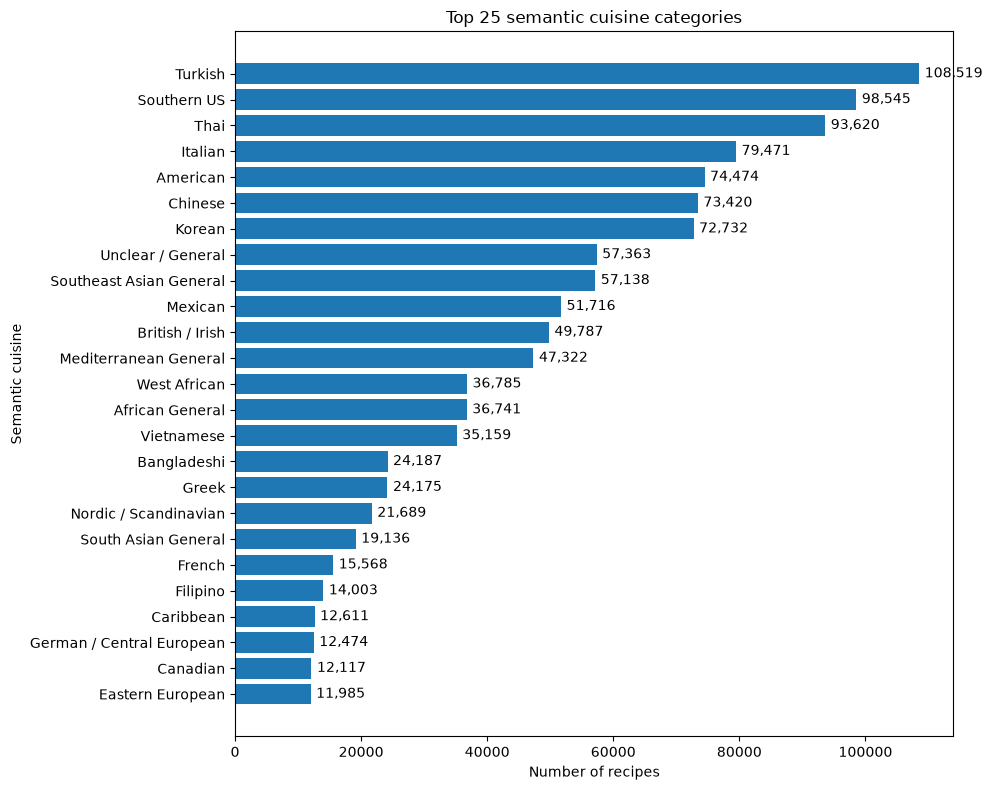

In [31]:
import matplotlib.pyplot as plt

top_n = 25

plot_df = (
    semantic_cuisine_stats
    .head(top_n)
    .sort_values("n_recipes", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(plot_df["semantic_cuisine"], plot_df["n_recipes"])

ax.set_xlabel("Number of recipes")
ax.set_ylabel("Semantic cuisine")
ax.set_title(f"Top {top_n} semantic cuisine categories")

ax.bar_label(bars, labels=[f"{v:,}" for v in plot_df["n_recipes"]], padding=4)

plt.tight_layout()
plt.show()

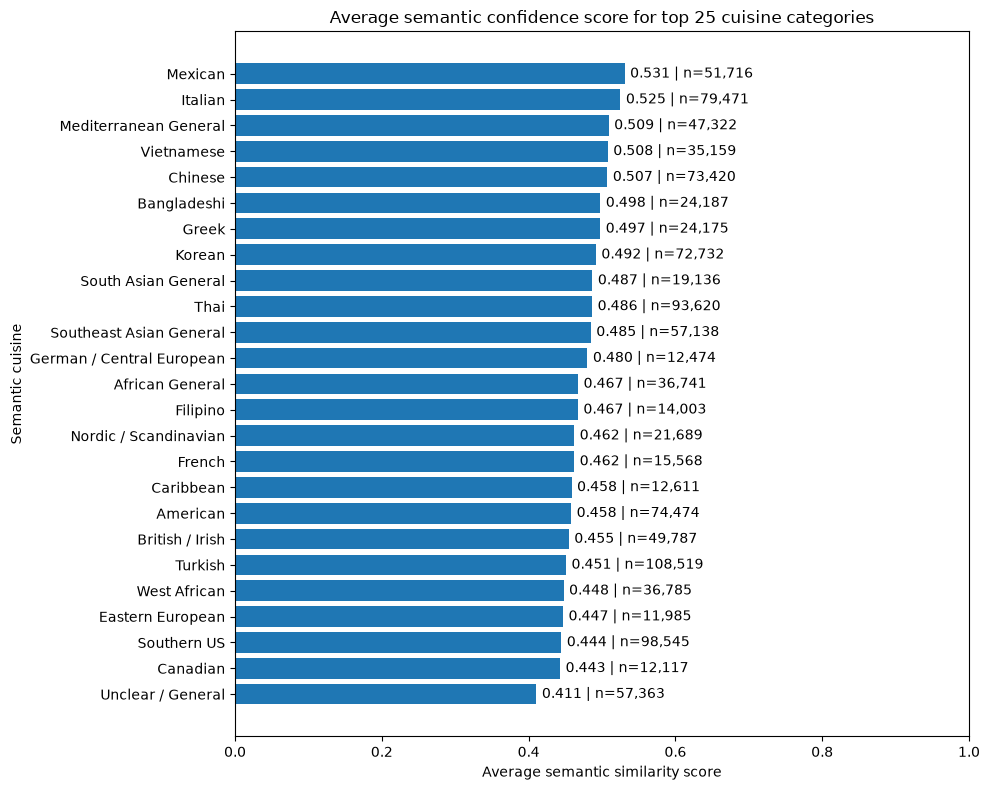

In [32]:
top_n = 25

plot_df = (
    semantic_cuisine_stats
    .head(top_n)
    .sort_values("avg_score", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(plot_df["semantic_cuisine"], plot_df["avg_score"])

ax.set_xlabel("Average semantic similarity score")
ax.set_ylabel("Semantic cuisine")
ax.set_title(f"Average semantic confidence score for top {top_n} cuisine categories")
ax.set_xlim(0, 1)

labels = [
    f"{score:.3f} | n={n:,}"
    for score, n in zip(plot_df["avg_score"], plot_df["n_recipes"])
]

ax.bar_label(bars, labels=labels, padding=4)

plt.tight_layout()
plt.show()

High-confidence recipes: 84345


,semantic_cuisine,n_recipes
0,Italian,16513
1,Mexican,14623
2,Chinese,8051
3,Mediterranean General,4845
4,Thai,4578
5,Korean,4212
6,American,4038
7,Southern US,3418
8,Turkish,2983
9,British / Irish,2241


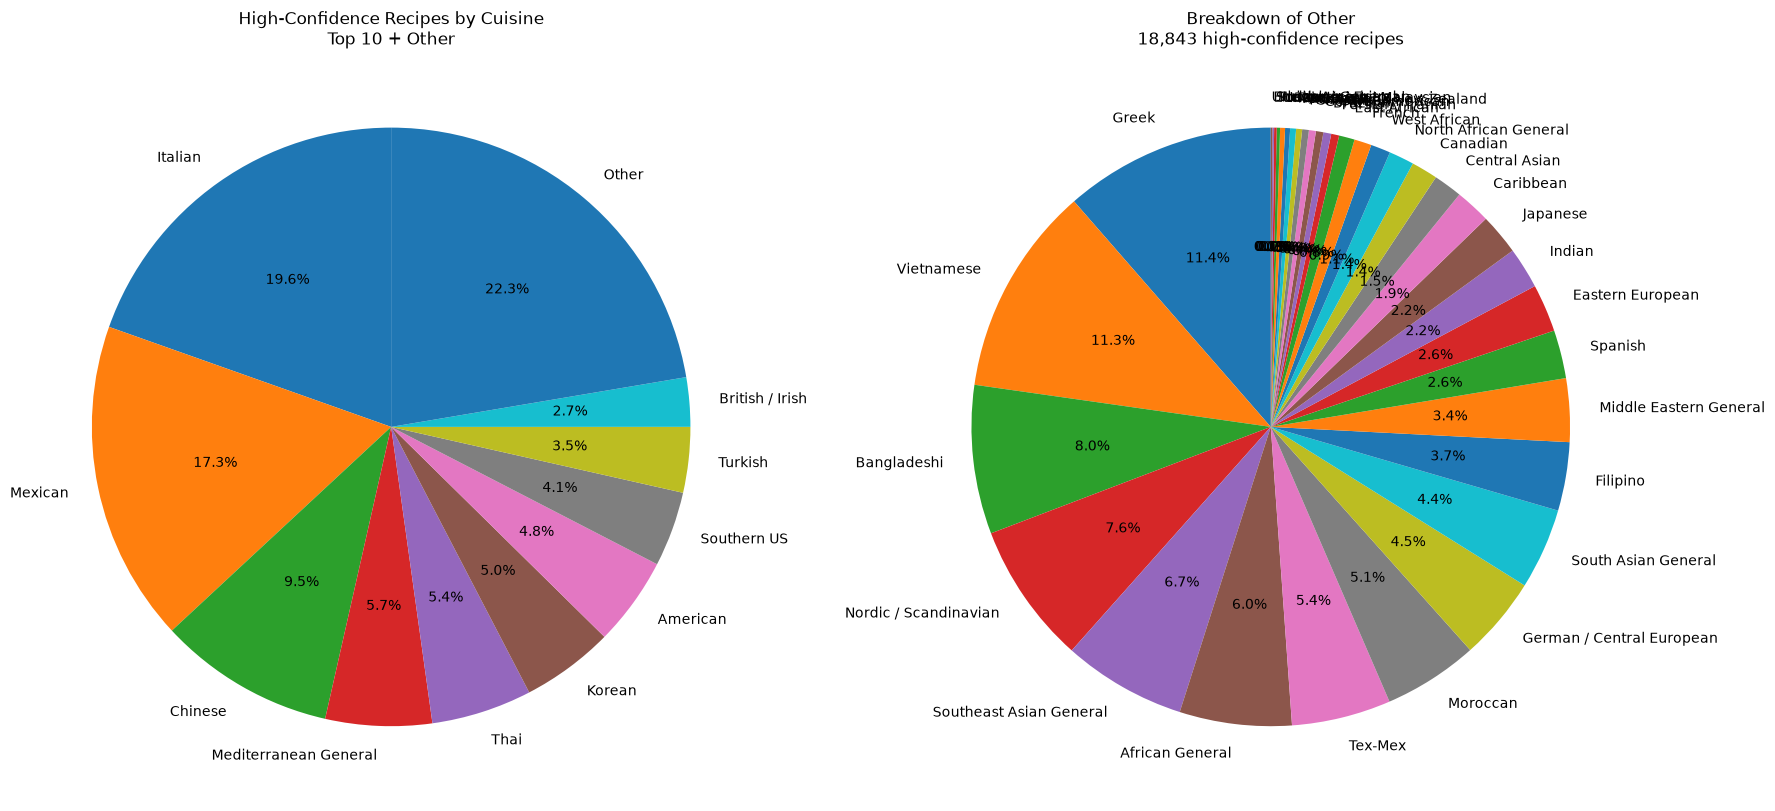

In [35]:
top_n = 10

# Keep only high-confidence semantic cuisine labels
high_conf_df = stats_df.loc[
    stats_df["semantic_cuisine_confidence"] == "high"
].copy()

high_conf_counts = (
    high_conf_df["semantic_cuisine"]
    .value_counts()
    .reset_index()
)

high_conf_counts.columns = ["semantic_cuisine", "n_recipes"]

print("High-confidence recipes:", len(high_conf_df))
display(high_conf_counts.head(30))

# Top cuisines for the main pie
top_counts = high_conf_counts.head(top_n).copy()

# Everything outside top_n becomes "Other" in the main pie
other_breakdown = high_conf_counts.iloc[top_n:].copy()
other_count = other_breakdown["n_recipes"].sum()

main_pie_counts = top_counts.copy()

if other_count > 0:
    main_pie_counts = pd.concat(
        [
            main_pie_counts,
            pd.DataFrame([{
                "semantic_cuisine": "Other",
                "n_recipes": other_count
            }])
        ],
        ignore_index=True
    )

# Create side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left chart: Top N + Other
axes[0].pie(
    main_pie_counts["n_recipes"],
    labels=main_pie_counts["semantic_cuisine"],
    autopct="%1.1f%%",
    startangle=90
)

axes[0].set_title(
    f"High-Confidence Recipes by Cuisine\nTop {top_n} + Other"
)

# Right chart: breakdown of Other
if other_count > 0:
    axes[1].pie(
        other_breakdown["n_recipes"],
        labels=other_breakdown["semantic_cuisine"],
        autopct="%1.1f%%",
        startangle=90
    )

    axes[1].set_title(
        f"Breakdown of Other\n{other_count:,} high-confidence recipes"
    )

else:
    axes[1].text(
        0.5,
        0.5,
        "No Other category",
        ha="center",
        va="center",
        fontsize=14
    )
    axes[1].set_title("Breakdown of Other")
    axes[1].axis("off")

plt.tight_layout()
plt.show()